# Analyse simulated trajectories

In [28]:
from time import time
import os

os.environ["JAX_PLATFORMS"] = "cpu"
os.environ["CUDA_VISIBLE_DEVICES"] = str(-1)

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from jax import config, jit
from jax.numpy.fft import fft, fftn, irfft, irfftn, rfft, rfftn, ifftn
from matplotlib.colors import LogNorm
from PIL import Image
from jax_sph.io_state import read_h5, write_h5

from l3es.init_fields import init_u_hit
from l3es.visualize import plot_views
from l3es.turbulence import mls_2nd_order

config.update("jax_enable_x64", True)

## 1. Start particle evolution from JAX-SPH relaxed trajectories

Relaxations based on jax-sph:
```bash
python main.py config=cases/tgv.yaml case.dim=2 case.mode=rlx solver.tvf=1.0 case.dx=0.03125 seed=42 case.r0_noise_factor=0.25 io.data_path=data_relaxed/ eos.p_bg_factor=0.02

python main.py config=cases/tgv.yaml case.dim=3 case.mode=rlx solver.tvf=1.0 case.dx=0.19634954 seed=42 case.r0_noise_factor=0.25 io.data_path=data_relaxed/ eos.p_bg_factor=0.02
```

In [30]:
### ! WARNING ! ###
# Run only once, as this rescales the TGV data

state_0_paths = [
    "../data_relaxed/tgv_2_0.03125_42.h5",
    "../data_relaxed/tgv_3_0.19634954_42.h5"
]

# remove all but coordinates from relaxed state
# and rescale 2D TGV to 2pi box
for path_i, rescale_factor in zip(state_0_paths, [2*np.pi, 1.0]):
    state_0 = read_h5(path_i)
    state_0 = {"r": state_0["r"]*rescale_factor}
    write_h5(state_0, path_i)

(0.0, 6.283185307179586)

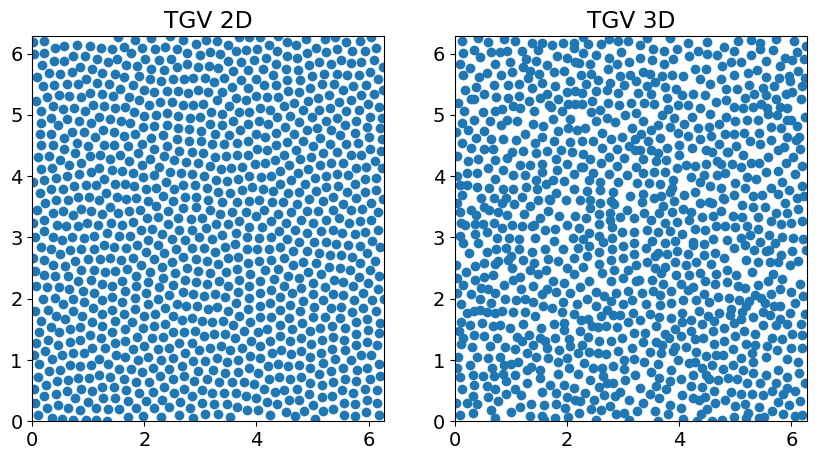

In [33]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

r = read_h5(state_0_paths[0])["r"]
axs[0].scatter(r[:, 0], r[:, 1])
axs[0].set_title("TGV 2D")
axs[0].set_xlim(0, 2*np.pi); axs[0].set_ylim(0, 2*np.pi)

r = read_h5(state_0_paths[1])["r"]
mask = r[:, 2] < 0.2
axs[1].scatter(r[:, 0][mask], r[:, 1][mask])
axs[1].set_title("TGV 3D")
axs[1].set_xlim(0, 2*np.pi); axs[1].set_ylim(0, 2*np.pi)

Generate GT with spectral method.
```bash
python main.py config=configs/kolmogorov.yaml
# t_tot = 41.083, t_sim = 0.278
```

Evolve particles.
```bash
python main.py config=configs/kolmogorov.yaml mode=integrate
# t_tot = 235.213, t_int = 218.198
```